In [8]:
# import packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.integrate import odeint
import torch
import os
from sklearn.model_selection import train_test_split
import seaborn as sns
sns.set_style("whitegrid")
from model import *
from torch.utils.data import DataLoader, Dataset

torch.set_default_dtype(torch.float64)

## Read Data and Process Data

In [3]:
#Read data from .csv file
approx_sol = pd.read_csv('eg2_sol.csv', sep=',')
approx_solut = approx_sol.to_numpy()

#Data properties
components = 1 #spatial dimensions
deltat = 0.04
t = np.arange(0, 1, deltat)
time_steps = len(t)
n_initial_cond = approx_solut.shape[0] #number of initial conditions for solutions

#Read True RHS from .csv file
true_der = pd.read_csv('eg2_true_RHS.csv', sep=',')
true_der = true_der.to_numpy()

#Read Difference Quotients from .csv file
Diff_quot = pd.read_csv('eg2_app_RHS.csv', sep=',')
Diff_quot = Diff_quot.to_numpy()

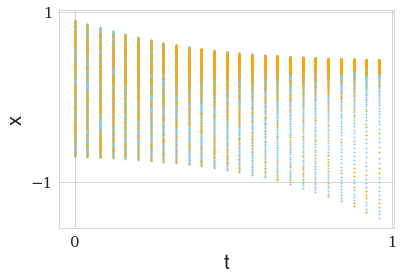

In [5]:
# Append t and x(t)
t_copy = np.tile(t, n_initial_cond).reshape(-1,1)
x_t = approx_solut.reshape(-1,1) 
inputs = np.append(t_copy, x_t, axis=1)
targets = Diff_quot.reshape(-1,1)

# train-test split 
X_train, X_test, Y_train, Y_test = train_test_split(inputs, targets, test_size=0.2)

# visualization
fontsize=15
plt.scatter(X_train[:,0], X_train[:,1], color='skyblue', s=1)
plt.scatter(X_test[:,0], X_test[:,1], color='orange', s=1)
plt.xticks([0,1], size = fontsize, fontname = 'serif')
plt.yticks([-1,1], size = fontsize, fontname = 'serif')
plt.xlabel('t', size=20)
plt.ylabel('x', size=20)
plt.savefig('samples_auto.pdf', bbox_inches = 'tight')

## Solution Estimation

In [30]:
# Setup Parameters
N = 50
sigma = 1
reg_param = 0.00001

W = np.random.randn(2,N) / sigma
b = np.random.uniform(0, 2*np.pi, size=(N,))
A = np.cos(X_train @ W + b) * np.sqrt(2/N)
c = np.linalg.solve(A.T@A + reg_param * np.diag(np.linalg.norm(W,axis=0)), A.T@Y_train)

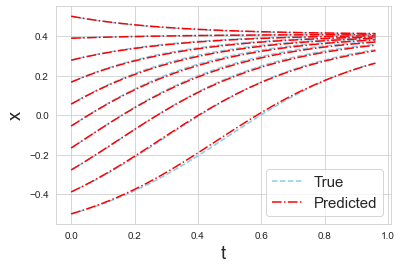

In [9]:
def g(x,t):
    A = np.cos(W[0] * t + W[1] * x + b)
    return np.sum(A * c.reshape(-1) * np.sqrt(2/N))

def fun(x, t):
    return np.cos(3*x) + x**3 - x

# time stamps
deltat = 0.04
t = np.arange(0, 1, deltat)
# 200 initial conditions
x_0 = np.linspace(-0.5,0.5,10)

for i in x_0:

    # solve
    sol = odeint(fun, i, t)
    sol_app = odeint(g, i, t)

    # transpose the solution, each row is a trajectory
    data = sol.T
    data1 = sol_app.T
    
    plt.plot(t, data.reshape(-1), '--', c='skyblue')
    plt.plot(t, data1.reshape(-1), '-.', c='red')

plt.legend(['True', 'Predicted'], fontsize=15 )
#plt.xticks(size=15)
#plt.yticks(size=15)
plt.xlabel('t', size=18)
plt.ylabel('x', size=18)
plt.savefig('Eg2_RF_sol.pdf', bbox_inches = 'tight')

## Define Random Features

In [10]:
n = 100 #grid points where we do the recovery

# Define real RHS
def z_func(t,x):
    return np.cos(3*x) + x**3 - x

#define recovery domain boundaries
x_low = -0.7
x_top = 0.9
t_low = 0
t_top = 1.

#generate grid of x and t in the recovery domain
x = np.linspace(x_low, x_top, n)
time1 = np.linspace(t_low, t_top, n)
T,X = np.meshgrid(time1,x)

#compute true RHS on grid
Z = z_func(T, X)

#Generate input for netowrk
new_X = X.reshape(-1,1)
new_T = T.reshape(-1,1)
X_new = np.append(new_T,new_X,axis = 1)

In [11]:
# Setup Parameters
N_range = range(10,201,10)      # number of features
sigma_range = np.linspace(0.2,4,20)  # variance parameter
T = 10                          # repeat T times
reg_param = 0.00001             # fixed regularization parameter

# record errors
train_errors = np.zeros((T, len(N_range), len(sigma_range)))
test_errors = np.zeros((T, len(N_range), len(sigma_range)))
non_rel_errors = np.zeros((T, len(N_range), len(sigma_range)))

Lip_cons = np.zeros((T, len(N_range), len(sigma_range)))

for t in range(T):
    
    for i in range(len(N_range)):
        
        N = N_range[i]
        
        for j in range(len(sigma_range)):
            
            sigma = sigma_range[j]
            W = np.random.randn(2,N) / sigma
            b = np.random.uniform(0, 2*np.pi, size=(N,))
            A = np.cos(X_train @ W + b) * np.sqrt(2/N)
            c = np.linalg.solve(A.T@A + reg_param * np.linalg.norm(W,axis=0), A.T@Y_train)
            
            # estimate Lipschitz constant
            Lip_cons[t,i,j] = np.sum( np.abs(c.reshape(-1)) * np.linalg.norm(W,axis=0) )

            # training loss
            train_errors[t,i,j] = np.mean((A @ c - Y_train)**2)

            # test loss
            A_test = np.cos(X_test @ W + b) * np.sqrt(2/N)
            test_errors[t,i,j] = np.mean((A_test @ c - Y_test)**2)

            # non-trajectory data relative errors
            A_non = np.cos(X_new @ W + b) * np.sqrt(2/N)
            Z_RF = A_non @ c
            Z_RF = Z_RF.reshape(n,n)
            non_rel_errors[t,i,j] = np.mean(abs(Z - Z_RF))/(np.abs(np.max(Z)-np.min(Z)))

In [13]:
np.savez_compressed('errors.npz', train=train_errors, test=test_errors, rel=non_rel_errors, Lip=Lip_cons)

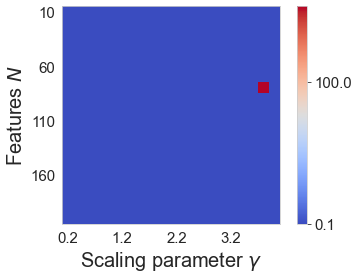

In [27]:
im = plt.imshow(np.mean(test_errors, axis=0), cmap='coolwarm')
plt.grid(visible=False)
cb = plt.colorbar(im,ticks=[0.1,100])
cb.ax.tick_params(labelsize=15)
plt.xticks([0,5,10,15],[0.2,1.2,2.2,3.2], size=15)
plt.yticks([0,5,10,15],[10, 60, 110, 160], size=15)
plt.xlabel(r'Scaling parameter $\gamma$', size=20)
plt.ylabel(r'Features $N$', size=20)
plt.savefig('Para_test_eg2.pdf', bbox_inches = 'tight')

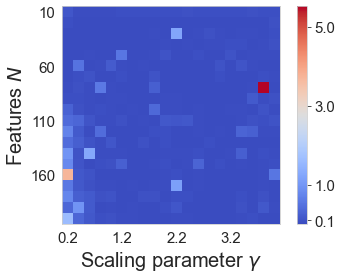

In [28]:
im = plt.imshow(np.mean(non_rel_errors, axis=0), cmap='coolwarm')
plt.grid(visible=False)
cb = plt.colorbar(im,ticks=[0.1,1,3,5])
cb.ax.tick_params(labelsize=15)
plt.xticks([0,5,10,15],[0.2,1.2,2.2,3.2], size=15)
plt.yticks([0,5,10,15],[10, 60, 110, 160], size=15)
plt.xlabel(r'Scaling parameter $\gamma$', size=20)
plt.ylabel(r'Features $N$', size=20)
plt.savefig('Para_rel_eg2.pdf', bbox_inches = 'tight')

Scaling parameter is 1.0
Slope is  -0.9148505807810138


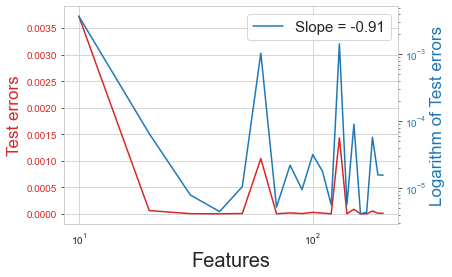

In [29]:
# Visualization: Line plot

# read data
#data = np.load('errors.npz')
#test_errors = data['test']
#non_rel_errors = data['rel']

# line plot for a fixed N
fig, ax1 = plt.subplots()

idx = 4
print('Scaling parameter is', sigma_range[idx])

color = 'tab:red'
ax1.set_xlabel('Features', size=20)
ax1.set_ylabel('Test errors', color=color, size=17)
ax1.plot(N_range, np.mean(test_errors,axis=0)[:,idx], color=color)
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()  # instantiate a second Axes that shares the same x-axis

k = np.polyfit(np.log(N_range), np.log(np.mean(test_errors,axis=0)[:,idx]), deg=1)[0]
print('Slope is ', k)

color = 'tab:blue'
ax2.set_ylabel('Logarithm of Test errors', color=color, size=17)  # we already handled the x-label with ax1
ax2.loglog(N_range, np.mean(test_errors,axis=0)[:,idx], color=color, label=f'Slope = {k:.2f}')
ax2.legend(fontsize=15)
ax2.tick_params(axis='y', labelcolor=color)

plt.grid(visible=False)
plt.savefig('Para_N_eg2.pdf', bbox_inches = 'tight')